In [1]:
# ============================================================
# EW Deployment Planner - Module B: RF Propagation & Physics
# Notebook: 01_propagation_analysis
# ============================================================

import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

# Project paths
PROJECT_ROOT = Path.cwd().parent.parent
MODULE_DIR = PROJECT_ROOT / "module_B_Propagation"
OUTPUT_DIR = MODULE_DIR / "outputs"
DATA_DIR = MODULE_DIR / "sample_data"

OUTPUT_DIR.mkdir(exist_ok=True)
DATA_DIR.mkdir(exist_ok=True)

print("Python:", sys.version)
print("Project root:", PROJECT_ROOT)
print("Output directory:", OUTPUT_DIR)

print("\nCore scientific stack loaded successfully.")

Python: 3.13.9 (tags/v3.13.9:8183fa5, Oct 14 2025, 14:09:13) [MSC v.1944 64 bit (AMD64)]
Project root: c:\Users\lenovo\EW-Deployment-Planner
Output directory: c:\Users\lenovo\EW-Deployment-Planner\module_B_Propagation\outputs

Core scientific stack loaded successfully.


In [2]:
# ============================================================
# 1. BASELINE RF SCENARIO
# ============================================================

scenario = {
    "frequency_mhz": 900.0,
    "tx_power_dbm": 30.0,
    "tx_height_m": 30.0,
    "rx_height_m": 10.0,
    "tx_gain_dbi": 2.0,
    "rx_gain_dbi": 2.0,
    "distance_km": 10.0,
}

scenario_df = pd.DataFrame([scenario])

scenario_df

,frequency_mhz,tx_power_dbm,tx_height_m,rx_height_m,tx_gain_dbi,rx_gain_dbi,distance_km
0,900.0,30.0,30.0,10.0,2.0,2.0,10.0


In [3]:
# ============================================================
# 2. FREE-SPACE PATH LOSS BASELINE
# ============================================================

def free_space_path_loss(distance_km, frequency_mhz):
    """
    Free-space path loss using:
    
    FSPL(dB) = 32.44 + 20 log10(d_km) + 20 log10(f_MHz)
    """
    return (
        32.44
        + 20 * np.log10(distance_km)
        + 20 * np.log10(frequency_mhz)
    )


fspl = free_space_path_loss(
    scenario["distance_km"],
    scenario["frequency_mhz"]
)

received_power_fs = (
    scenario["tx_power_dbm"]
    + scenario["tx_gain_dbi"]
    + scenario["rx_gain_dbi"]
    - fspl
)

print(f"Frequency       : {scenario['frequency_mhz']:.1f} MHz")
print(f"Distance        : {scenario['distance_km']:.1f} km")
print(f"Free-space loss : {fspl:.2f} dB")
print(f"Received power  : {received_power_fs:.2f} dBm")

Frequency       : 900.0 MHz
Distance        : 10.0 km
Free-space loss : 111.52 dB
Received power  : -77.52 dBm


Tx ground elevation : 120.0 m
Rx ground elevation : 140.8 m
Tx antenna elevation: 150.0 m
Rx antenna elevation: 150.8 m
Maximum terrain     : 265.1 m


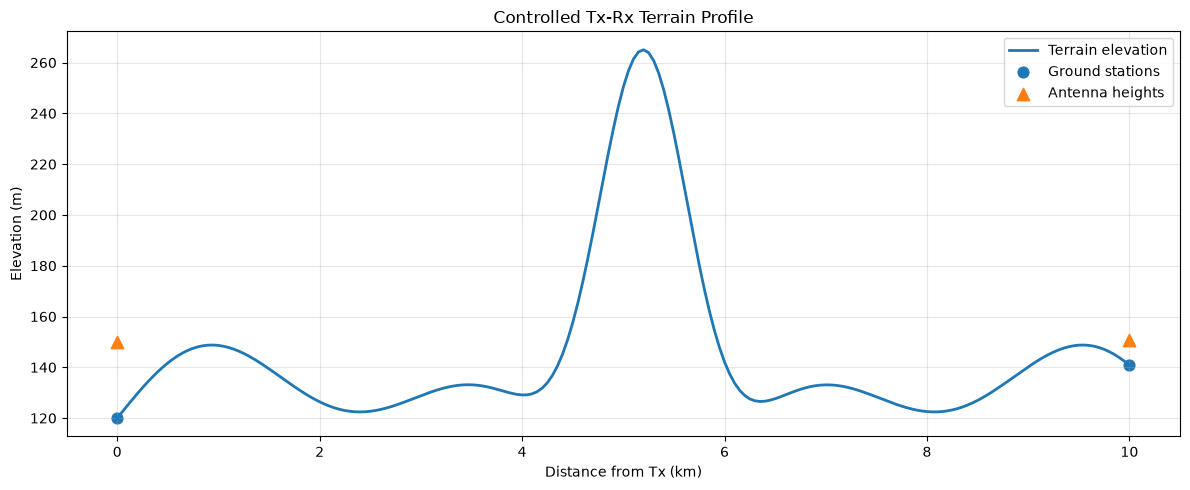

In [5]:
# ============================================================
# 3. CONTROLLED TERRAIN PROFILE
# ============================================================

# Distance along the Tx -> Rx path
distance_km = np.linspace(0, 10, 201)

# Synthetic terrain elevation in metres above sea level
terrain_m = (
    120
    + 20 * np.sin(distance_km * 0.9)
    + 15 * np.sin(distance_km * 2.1)
)

# Add a dominant ridge between Tx and Rx
ridge = 180 * np.exp(
    -((distance_km - 5.2) ** 2) / (2 * 0.45 ** 2)
)

terrain_m += ridge

# Antenna ground elevations
tx_ground_m = terrain_m[0]
rx_ground_m = terrain_m[-1]

# Antenna absolute elevations
tx_elevation_m = tx_ground_m + scenario["tx_height_m"]
rx_elevation_m = rx_ground_m + scenario["rx_height_m"]

print(f"Tx ground elevation : {tx_ground_m:.1f} m")
print(f"Rx ground elevation : {rx_ground_m:.1f} m")
print(f"Tx antenna elevation: {tx_elevation_m:.1f} m")
print(f"Rx antenna elevation: {rx_elevation_m:.1f} m")
print(f"Maximum terrain     : {terrain_m.max():.1f} m")

# Plot terrain
plt.figure(figsize=(12, 5))

plt.plot(
    distance_km,
    terrain_m,
    linewidth=2,
    label="Terrain elevation"
)

plt.scatter(
    [0, 10],
    [tx_ground_m, rx_ground_m],
    s=60,
    label="Ground stations"
)

plt.scatter(
    [0, 10],
    [tx_elevation_m, rx_elevation_m],
    s=80,
    marker="^",
    label="Antenna heights"
)

plt.xlabel("Distance from Tx (km)")
plt.ylabel("Elevation (m)")
plt.title("Controlled Tx-Rx Terrain Profile")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Minimum terrain clearance: -114.64 m
Critical point: 5.20 km


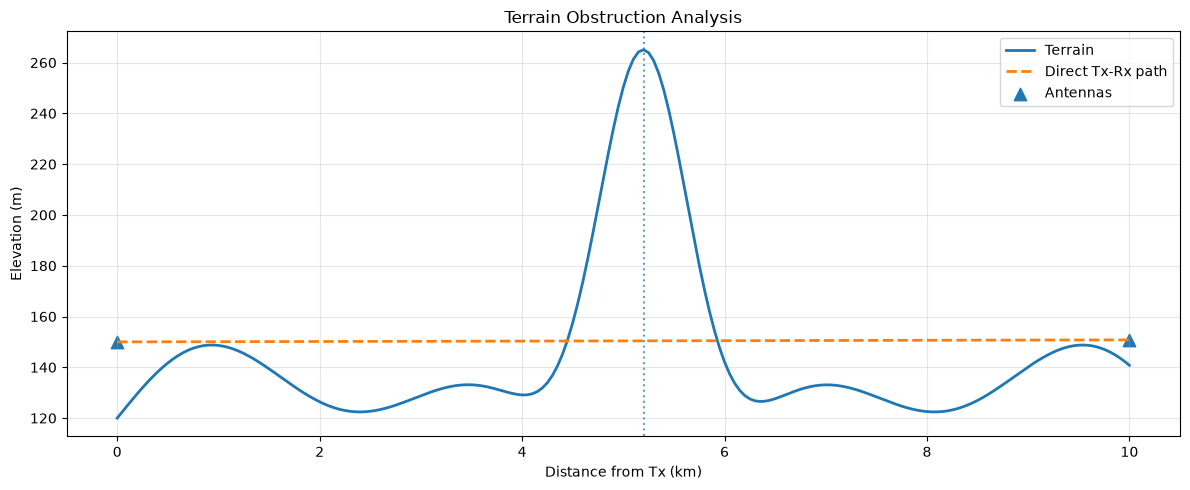

In [6]:
# ============================================================
# 4. DIRECT RADIO PATH
# ============================================================

# Straight line between the two antenna elevations
direct_path_m = np.linspace(
    tx_elevation_m,
    rx_elevation_m,
    len(distance_km)
)

# Terrain clearance relative to the direct path
clearance_m = direct_path_m - terrain_m

# Find the minimum clearance
min_clearance = clearance_m.min()
critical_index = np.argmin(clearance_m)

print(f"Minimum terrain clearance: {min_clearance:.2f} m")
print(
    f"Critical point: "
    f"{distance_km[critical_index]:.2f} km"
)

# Plot terrain + direct path
plt.figure(figsize=(12, 5))

plt.plot(
    distance_km,
    terrain_m,
    linewidth=2,
    label="Terrain"
)

plt.plot(
    distance_km,
    direct_path_m,
    linestyle="--",
    linewidth=2,
    label="Direct Tx-Rx path"
)

plt.scatter(
    [0, 10],
    [tx_elevation_m, rx_elevation_m],
    s=80,
    marker="^",
    label="Antennas"
)

plt.axvline(
    distance_km[critical_index],
    linestyle=":",
    alpha=0.7
)

plt.xlabel("Distance from Tx (km)")
plt.ylabel("Elevation (m)")
plt.title("Terrain Obstruction Analysis")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
# ============================================================
# 5. CHECK Py1812 DIGITAL MAP DATA
# ============================================================

import Py1812
import os

py1812_path = os.path.dirname(Py1812.__file__)

print("Py1812 location:")
print(py1812_path)

print("\nContents:")
for item in os.listdir(py1812_path):
    print(" -", item)

Py1812 location:
c:\Users\lenovo\EW-Deployment-Planner\.venv\Lib\site-packages\Py1812

Contents:
 - initiate_digital_maps.py
 - maps
 - P1812.py
 - __init__.py
 - __pycache__


In [9]:

# ============================================================
# 6. INSPECT P.1812 API
# ============================================================

from Py1812 import P1812
import inspect

print("P.1812 available functions:")
print([name for name in dir(P1812) if not name.startswith("_")])

print("\n--- bt_loss signature ---")
print(inspect.signature(P1812.bt_loss))

print("\n--- module location ---")
print(P1812.__file__)

P.1812 available functions:
['C', 'DigitalMaps', 'DigitalMapsNpz', 'SG3DB', 'T', 'asind', 'atan2d', 'beta0', 'bt_loss', 'clutter', 'cosd', 'datetime', 'dl_bull', 'dl_bull_att4', 'dl_delta_bull', 'dl_p', 'dl_se', 'dl_se_ft', 'dl_se_ft_inner', 'earth_rad_eff', 'files', 'find_intervals', 'great_circle_path', 'interp2', 'inv_cum_norm', 'isempty', 'issorted', 'k', 'longest_cont_dist', 'np', 'os', 'path_fraction', 'pl_los', 'read_sg3_measurements2', 'sind', 'smooth_earth_heights', 'stdDev', 'strcmp', 'tl_anomalous', 'tl_tropo']

--- bt_loss signature ---
(f, p, d, h, R, zone, htg, hrg, pol, phi_t, phi_r, lam_t, lam_r, **kwargs)

--- module location ---
c:\Users\lenovo\EW-Deployment-Planner\.venv\Lib\site-packages\Py1812\P1812.py


In [10]:
# ============================================================
# 7. P.1812 PROPAGATION RUN
# ============================================================

from Py1812 import P1812

# P.1812 inputs
f_ghz = scenario["frequency_mhz"] / 1000.0
time_percentage = 50.0

# Use our existing terrain profile
d = distance_km.copy()
h = terrain_m.copy()

# No additional clutter in this controlled experiment
R = np.zeros_like(h)

# Entire path is inland
zone = np.full(len(d), 4, dtype=int)

# Antenna heights above ground
htg = scenario["tx_height_m"]
hrg = scenario["rx_height_m"]

# Horizontal polarization
pol = 1

# Synthetic geographic coordinates.
# These are only used to define the path geometry.
phi_t = 19.0000
phi_r = 19.0000

lam_t = 72.0000
lam_r = 72.0955

# Tx power: 30 dBm = 1 W = 0.001 kW
ptx_kw = 0.001

# Antenna gains
gtx_dbi = scenario["tx_gain_dbi"]
grx_dbi = scenario["rx_gain_dbi"]

# Run ITU-R P.1812
Lb, Ep = P1812.bt_loss(
    f_ghz,
    time_percentage,
    d,
    h,
    R,
    zone,
    htg,
    hrg,
    pol,
    phi_t,
    phi_r,
    lam_t,
    lam_r,
    Ptx=ptx_kw,
    Gtx=gtx_dbi,
    Grx=grx_dbi,
)

print("P.1812 RESULT")
print("-" * 40)
print(f"Frequency              : {f_ghz:.3f} GHz")
print(f"Path distance          : {d[-1]:.2f} km")
print(f"Time percentage        : {time_percentage:.1f}%")
print(f"Basic transmission loss: {Lb:.2f} dB")
print(f"Field strength         : {Ep:.2f} dBuV/m")

P.1812 RESULT
----------------------------------------
Frequency              : 0.900 GHz
Path distance          : 10.00 km
Time percentage        : 50.0%
Basic transmission loss: 149.52 dB
Field strength         : 22.92 dBuV/m


In [11]:
# Longley-Rice / ITM point-to-point propagation

import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Load the cloned ITM implementation
ITM_SOURCE = PROJECT_ROOT / "itm_source"
if str(ITM_SOURCE) not in sys.path:
    sys.path.insert(0, str(ITM_SOURCE))

import itm

# Reset ITM state
itm.dictionaries()

# -----------------------------
# ITM configuration
# -----------------------------
frequency_mhz = 900.0
tx_height_m = 30.0
rx_height_m = 10.0

# Continental temperate climate
itm.prop['hg'][0] = tx_height_m
itm.prop['hg'][1] = rx_height_m
itm.propv['klim'] = itm.cContTemp

# Point-to-point mode
itm.mdvarSet(itm.mRandom)
itm.mdvarSet(itm.mPfl)

# Ground / propagation parameters
polarization = 'v'
ground_permittivity = 15.0
ground_conductivity = 0.005
surface_refractivity = 301.0

# Prepare model
itm.lrPrep(
    frequency_mhz,
    0,
    surface_refractivity,
    polarization,
    ground_permittivity,
    ground_conductivity
)

# Terrain profile
rng_m = distance_km * 1000.0
pfl_m = terrain_m

# Run ITM
itm.lrProfile(rng_m, pfl_m)

# Free-space loss
fs_loss_db = itm.freespace_dB(
    frequency_mhz * 1e6,
    rng_m[-1]
)

# 50% time / location / situation quantile
from scipy.stats import norm

z = norm.isf(0.50)

attenuation_db, sigma_db = itm.aVar(z, 0, z)
itm_loss_db = float(fs_loss_db + attenuation_db)

# Received power
tx_power_dbm = 30.0
tx_gain_dbi = 2.0
rx_gain_dbi = 2.0

rx_power_itm_dbm = (
    tx_power_dbm
    + tx_gain_dbi
    + rx_gain_dbi
    - itm_loss_db
)

# Propagation mode
mode_1, mode_2 = itm.propMode(pfl_m)

print("Longley-Rice / ITM Result")
print("-" * 40)
print(f"Model version: {itm.version}")
print(f"Frequency: {frequency_mhz:.1f} MHz")
print(f"Path distance: {rng_m[-1]/1000:.2f} km")
print(f"Free-space loss: {fs_loss_db:.2f} dB")
print(f"ITM basic transmission loss: {itm_loss_db:.2f} dB")
print(f"Received power: {rx_power_itm_dbm:.2f} dBm")
print(f"Propagation geometry: {mode_1}")
print(f"Dominant mechanism: {mode_2 if mode_2 else 'Line-of-sight'}")

errors, warnings = itm.errors()

if warnings:
    print("\nWarnings:")
    for w in warnings:
        print(" -", w)

if errors:
    print("\nErrors:")
    for e in errors:
        print(" -", e)

Longley-Rice / ITM Result
----------------------------------------
Model version: 1.2.2
Frequency: 900.0 MHz
Path distance: 10.00 km
Free-space loss: 111.53 dB
ITM basic transmission loss: 166.67 dB
Received power: -132.67 dBm
Propagation geometry: d
Dominant mechanism: d

Errors:
 - Earth horizons error.


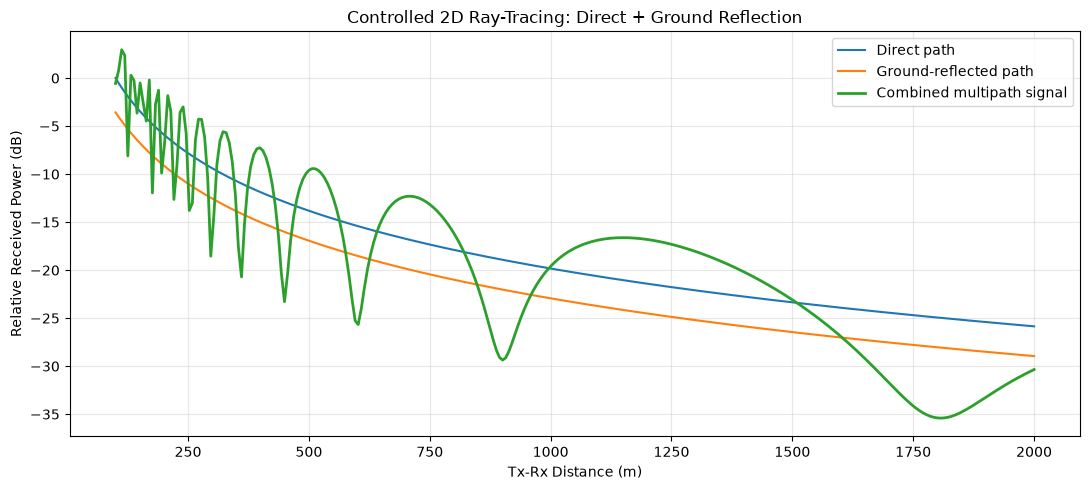

Ray-tracing plot saved to: c:\Users\lenovo\EW-Deployment-Planner\module_B_Propagation\outputs\ray_tracing_multipath.png
Wavelength at 900 MHz: 0.333 m


In [12]:
# ---------------------------------------------------------
# Controlled 2D Ray Tracing: Direct + Ground Reflection
# ---------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt

c = 299792458.0
f_hz = 900e6
wavelength = c / f_hz

tx_h = 30.0
rx_h = 10.0

# Receiver positions from 100 m to 2 km
rx_distances = np.linspace(100, 2000, 300)

# Reflection coefficient for controlled ground-reflection experiment
gamma = -0.7

direct_power = []
reflected_power = []
combined_power = []
direct_angles = []
reflected_angles = []

for d in rx_distances:

    # Direct path
    direct_distance = np.sqrt(
        d**2 + (tx_h - rx_h)**2
    )

    # Image-source method for ground reflection
    reflected_distance = np.sqrt(
        d**2 + (tx_h + rx_h)**2
    )

    # Complex field amplitudes
    E_direct = (
        np.exp(-1j * 2 * np.pi * direct_distance / wavelength)
        / direct_distance
    )

    E_reflected = (
        gamma
        * np.exp(-1j * 2 * np.pi * reflected_distance / wavelength)
        / reflected_distance
    )

    E_total = E_direct + E_reflected

    direct_power.append(abs(E_direct)**2)
    reflected_power.append(abs(E_reflected)**2)
    combined_power.append(abs(E_total)**2)

    # Propagation angles
    direct_angles.append(
        np.degrees(np.arctan2(tx_h - rx_h, d))
    )

    reflected_angles.append(
        np.degrees(np.arctan2(tx_h + rx_h, d))
    )

direct_power = np.array(direct_power)
reflected_power = np.array(reflected_power)
combined_power = np.array(combined_power)

# Normalize to the direct signal at 100 m
reference = direct_power[0]

direct_db = 10 * np.log10(direct_power / reference)
reflected_db = 10 * np.log10(reflected_power / reference)
combined_db = 10 * np.log10(combined_power / reference)

# ---------------------------------------------------------
# Plot multipath interference
# ---------------------------------------------------------

plt.figure(figsize=(11, 5))

plt.plot(
    rx_distances,
    direct_db,
    label="Direct path"
)

plt.plot(
    rx_distances,
    reflected_db,
    label="Ground-reflected path"
)

plt.plot(
    rx_distances,
    combined_db,
    label="Combined multipath signal",
    linewidth=2
)

plt.xlabel("Tx-Rx Distance (m)")
plt.ylabel("Relative Received Power (dB)")
plt.title("Controlled 2D Ray-Tracing: Direct + Ground Reflection")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

raytrace_plot = OUTPUT_DIR / "ray_tracing_multipath.png"
plt.savefig(raytrace_plot, dpi=200, bbox_inches="tight")
plt.show()

print(f"Ray-tracing plot saved to: {raytrace_plot}")
print(f"Wavelength at 900 MHz: {wavelength:.3f} m")

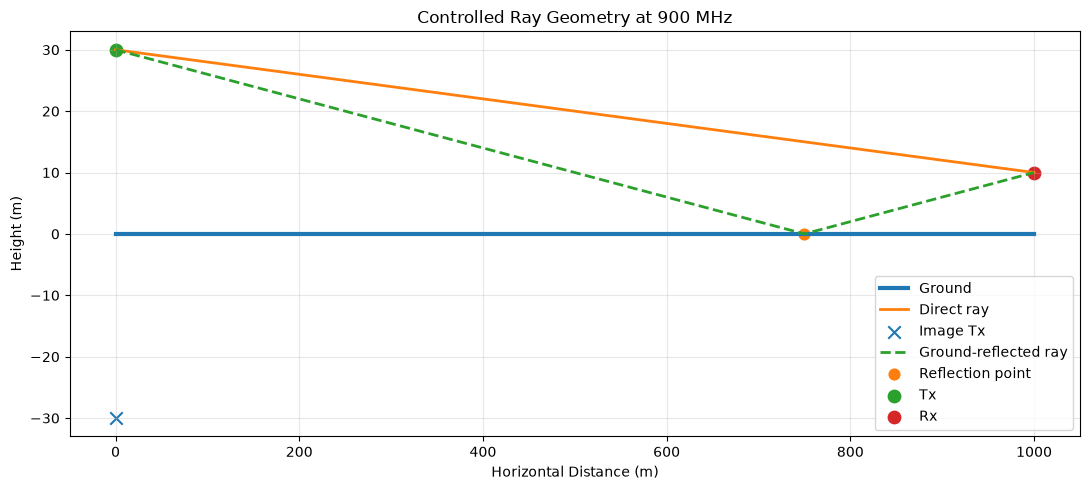

Geometry plot saved to: c:\Users\lenovo\EW-Deployment-Planner\module_B_Propagation\outputs\ray_tracing_geometry.png
Direct path length: 1000.20 m
Reflected path length: 1000.80 m
Reflection point: 750.00 m


In [13]:
# ---------------------------------------------------------
# Ray Geometry Visualization
# ---------------------------------------------------------

d = 1000.0

direct_distance = np.sqrt(
    d**2 + (tx_h - rx_h)**2
)

reflected_distance = np.sqrt(
    d**2 + (tx_h + rx_h)**2
)

plt.figure(figsize=(11, 5))

# Ground
plt.plot(
    [0, d],
    [0, 0],
    linewidth=3,
    label="Ground"
)

# Direct ray
plt.plot(
    [0, d],
    [tx_h, rx_h],
    linewidth=2,
    label="Direct ray"
)

# Image transmitter
plt.scatter(
    0,
    -tx_h,
    marker="x",
    s=80,
    label="Image Tx"
)

# Reflected ray
reflection_x = d * tx_h / (tx_h + rx_h)
reflection_y = 0

plt.plot(
    [0, reflection_x, d],
    [tx_h, reflection_y, rx_h],
    linewidth=2,
    linestyle="--",
    label="Ground-reflected ray"
)

plt.scatter(
    reflection_x,
    reflection_y,
    s=60,
    label="Reflection point"
)

plt.scatter(
    0,
    tx_h,
    s=80,
    label="Tx"
)

plt.scatter(
    d,
    rx_h,
    s=80,
    label="Rx"
)

plt.xlabel("Horizontal Distance (m)")
plt.ylabel("Height (m)")
plt.title("Controlled Ray Geometry at 900 MHz")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

geometry_plot = OUTPUT_DIR / "ray_tracing_geometry.png"
plt.savefig(geometry_plot, dpi=200, bbox_inches="tight")
plt.show()

print(f"Geometry plot saved to: {geometry_plot}")
print(f"Direct path length: {direct_distance:.2f} m")
print(f"Reflected path length: {reflected_distance:.2f} m")
print(f"Reflection point: {reflection_x:.2f} m")

In [14]:
# ---------------------------------------------------------
# Propagation Model Comparison
# ---------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Basic scenario values
distance_km_value = float(distance_km[-1])
frequency_mhz = 900.0

# FSPL already calculated earlier
fspl_db = float(fspl)

# P.1812 result from the earlier cell
p1812_loss_db = float(np.asarray(Lb).squeeze())

# ITM result from the Longley-Rice cell
itm_loss_db = float(itm_loss_db)

comparison = pd.DataFrame({
    "Model": [
        "Free-Space",
        "ITU-R P.1812",
        "Longley-Rice / ITM"
    ],
    "Frequency_MHz": [
        frequency_mhz,
        frequency_mhz,
        frequency_mhz
    ],
    "Distance_km": [
        distance_km_value,
        distance_km_value,
        distance_km_value
    ],
    "Path_Loss_dB": [
        fspl_db,
        p1812_loss_db,
        itm_loss_db
    ]
})

comparison["Received_Power_dBm"] = (
    scenario["tx_power_dbm"]
    + scenario["tx_gain_dbi"]
    + scenario["rx_gain_dbi"]
    - comparison["Path_Loss_dB"]
)

display(comparison)

# Save CSV
comparison_csv = OUTPUT_DIR / "propagation_model_comparison.csv"
comparison.to_csv(comparison_csv, index=False)

# Save JSON
comparison_json = OUTPUT_DIR / "propagation_model_comparison.json"
comparison.to_json(comparison_json, orient="records", indent=2)

print(f"\nCSV saved: {comparison_csv}")
print(f"JSON saved: {comparison_json}")

,Model,Frequency_MHz,Distance_km,Path_Loss_dB,Received_Power_dBm
0,Free-Space,900.0,10.0,111.524850,-77.524850
1,ITU-R P.1812,900.0,10.0,149.523213,-115.523213
2,Longley-Rice / ITM,900.0,10.0,166.674592,-132.674592



CSV saved: c:\Users\lenovo\EW-Deployment-Planner\module_B_Propagation\outputs\propagation_model_comparison.csv
JSON saved: c:\Users\lenovo\EW-Deployment-Planner\module_B_Propagation\outputs\propagation_model_comparison.json


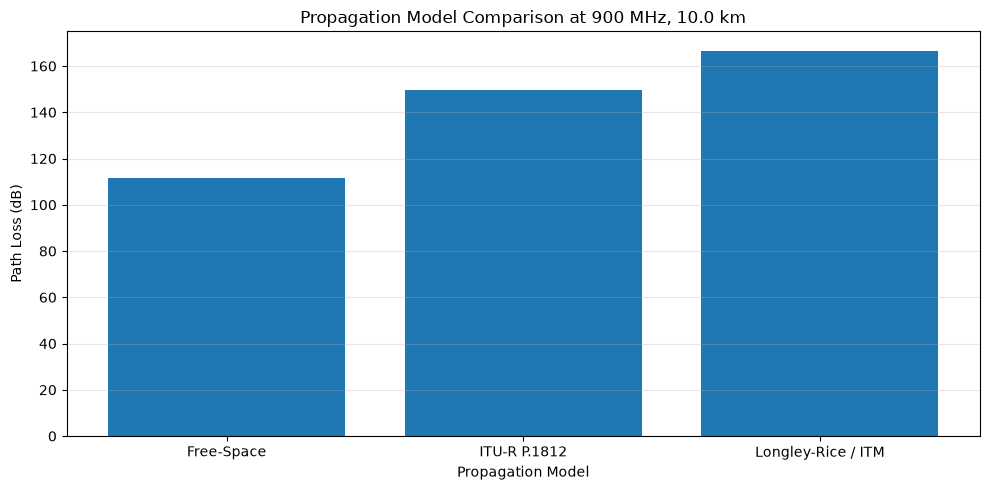

Plot saved: c:\Users\lenovo\EW-Deployment-Planner\module_B_Propagation\outputs\propagation_model_comparison.png


In [15]:
# ---------------------------------------------------------
# Model Comparison Plot
# ---------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.bar(
    comparison["Model"],
    comparison["Path_Loss_dB"]
)

plt.ylabel("Path Loss (dB)")
plt.xlabel("Propagation Model")
plt.title(
    f"Propagation Model Comparison at {frequency_mhz:.0f} MHz, "
    f"{distance_km_value:.1f} km"
)

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

comparison_plot = OUTPUT_DIR / "propagation_model_comparison.png"
plt.savefig(comparison_plot, dpi=200, bbox_inches="tight")
plt.show()

print(f"Plot saved: {comparison_plot}")

In [16]:
# ---------------------------------------------------------
# Save Terrain Profile + Propagation Analysis Results
# ---------------------------------------------------------

# Terrain profile CSV
terrain_df = pd.DataFrame({
    "distance_km": distance_km,
    "terrain_elevation_m": terrain_m,
    "direct_path_elevation_m": direct_path_m,
    "clearance_m": clearance_m
})

terrain_csv = OUTPUT_DIR / "terrain_profile_analysis.csv"
terrain_df.to_csv(terrain_csv, index=False)

# Ray-tracing results CSV
raytrace_df = pd.DataFrame({
    "distance_m": rx_distances,
    "direct_relative_power_db": direct_db,
    "reflected_relative_power_db": reflected_db,
    "combined_multipath_power_db": combined_db,
    "direct_angle_deg": direct_angles,
    "reflected_angle_deg": reflected_angles
})

raytrace_csv = OUTPUT_DIR / "ray_tracing_results.csv"
raytrace_df.to_csv(raytrace_csv, index=False)

# Combined technical summary
technical_summary = {
    "scenario": {
        "frequency_MHz": 900.0,
        "tx_power_dBm": 30.0,
        "tx_height_m": 30.0,
        "rx_height_m": 10.0,
        "tx_gain_dBi": 2.0,
        "rx_gain_dBi": 2.0,
        "distance_km": distance_km_value
    },
    "terrain_analysis": {
        "profile_type": "Synthetic controlled terrain profile",
        "minimum_clearance_m": float(min_clearance),
        "critical_point_km": float(distance_km[critical_index])
    },
    "propagation_models": comparison.to_dict(orient="records"),
    "ray_tracing": {
        "method": "2D geometric optics",
        "reflection": "Ground reflection using image-source method",
        "frequency_MHz": 900.0,
        "wavelength_m": float(wavelength),
        "reflection_coefficient": gamma
    }
}

import json

summary_json = OUTPUT_DIR / "propagation_analysis_summary.json"

with open(summary_json, "w", encoding="utf-8") as f:
    json.dump(technical_summary, f, indent=2)

print("OUTPUT PACKAGE CREATED")
print("-" * 50)
print(f"Terrain profile : {terrain_csv}")
print(f"Ray tracing     : {raytrace_csv}")
print(f"Summary JSON    : {summary_json}")
print(f"Model comparison: {comparison_csv}")
print(f"Model JSON      : {comparison_json}")

OUTPUT PACKAGE CREATED
--------------------------------------------------
Terrain profile : c:\Users\lenovo\EW-Deployment-Planner\module_B_Propagation\outputs\terrain_profile_analysis.csv
Ray tracing     : c:\Users\lenovo\EW-Deployment-Planner\module_B_Propagation\outputs\ray_tracing_results.csv
Summary JSON    : c:\Users\lenovo\EW-Deployment-Planner\module_B_Propagation\outputs\propagation_analysis_summary.json
Model comparison: c:\Users\lenovo\EW-Deployment-Planner\module_B_Propagation\outputs\propagation_model_comparison.csv
Model JSON      : c:\Users\lenovo\EW-Deployment-Planner\module_B_Propagation\outputs\propagation_model_comparison.json


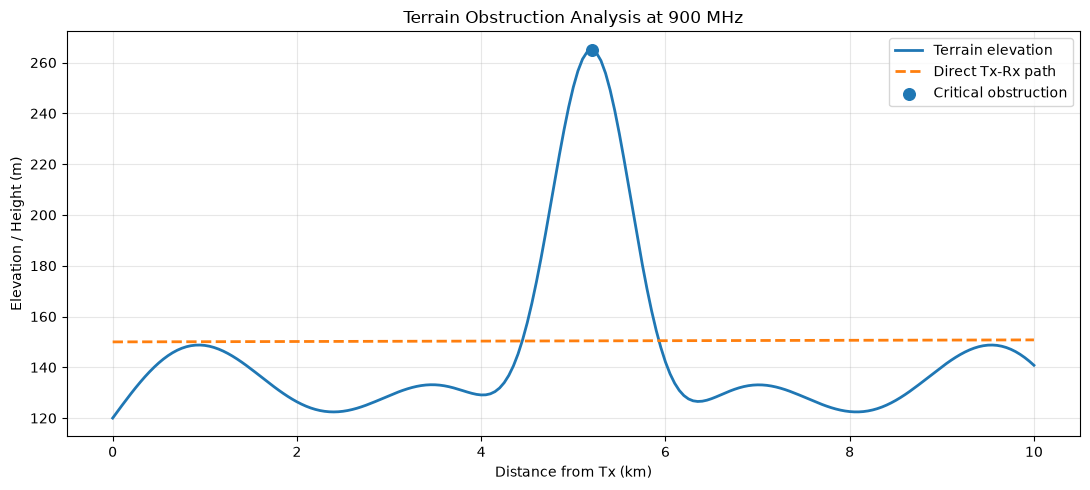

Saved: c:\Users\lenovo\EW-Deployment-Planner\module_B_Propagation\outputs\terrain_obstruction_analysis.png
Minimum clearance: -114.64 m
Critical point: 5.20 km


In [17]:
# ---------------------------------------------------------
# Terrain + Line-of-Sight Obstruction Plot
# ---------------------------------------------------------

plt.figure(figsize=(11, 5))

plt.plot(
    distance_km,
    terrain_m,
    linewidth=2,
    label="Terrain elevation"
)

plt.plot(
    distance_km,
    direct_path_m,
    linestyle="--",
    linewidth=2,
    label="Direct Tx-Rx path"
)

plt.scatter(
    distance_km[critical_index],
    terrain_m[critical_index],
    s=70,
    label="Critical obstruction"
)

plt.xlabel("Distance from Tx (km)")
plt.ylabel("Elevation / Height (m)")
plt.title("Terrain Obstruction Analysis at 900 MHz")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

terrain_plot = OUTPUT_DIR / "terrain_obstruction_analysis.png"
plt.savefig(terrain_plot, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved: {terrain_plot}")
print(f"Minimum clearance: {min_clearance:.2f} m")
print(f"Critical point: {distance_km[critical_index]:.2f} km")

In [18]:
# ---------------------------------------------------------
# Person 2 Technical Notes
# ---------------------------------------------------------

notes = f"""# RF Propagation & Physics Module

## 1. Objective

This module evaluates radio-frequency propagation between transmitter and
receiver locations using large-scale propagation models and a controlled
ray-tracing experiment.

The implementation is standalone and does not depend on QGIS or the
deployment optimizer.

## 2. Controlled Scenario

- Frequency: 900 MHz
- Transmit power: 30 dBm
- Transmitter height: 30 m
- Receiver height: 10 m
- Tx antenna gain: 2 dBi
- Rx antenna gain: 2 dBi
- Tx-Rx distance: {distance_km_value:.1f} km
- Terrain: synthetic controlled elevation profile

## 3. Terrain Analysis

A controlled terrain profile containing a pronounced ridge was generated to
demonstrate obstruction of the direct Tx-Rx path.

Observed minimum clearance:

{min_clearance:.2f} m

Critical obstruction location:

{distance_km[critical_index]:.2f} km

The negative clearance indicates that the terrain rises above the direct
geometric path at the critical location.

## 4. Propagation Models

### Free-Space Path Loss

Free-space path loss provides a baseline assuming unobstructed propagation
without terrain effects.

### ITU-R P.1812

ITU-R P.1812 was used as a terrain-aware propagation model. The official
digital map products were initialized and the model was evaluated for the
controlled terrain profile.

### Longley-Rice / ITM

The Longley-Rice implementation was evaluated using a point-to-point terrain
profile. This provides an independent terrain-aware propagation estimate.

## 5. Ray Tracing

A controlled two-dimensional geometric-optics experiment was implemented
using:

- Direct propagation
- Ground reflection
- Image-source construction
- Complex field superposition
- Path-length-dependent phase
- Reflection coefficient

At 900 MHz the wavelength is approximately {wavelength:.3f} m.

The combined direct and reflected fields produce constructive and destructive
interference, demonstrating multipath fading.

## 6. Model Comparison

The generated comparison results are stored in:

`propagation_model_comparison.csv`

and

`propagation_model_comparison.json`

The comparison should be interpreted as a controlled engineering experiment.
Free-space propagation represents an ideal baseline, while P.1812 and
Longley-Rice account for terrain-related propagation effects.

## 7. Generated Outputs

- `terrain_profile_analysis.csv`
- `ray_tracing_results.csv`
- `propagation_model_comparison.csv`
- `propagation_model_comparison.json`
- `propagation_analysis_summary.json`
- `terrain_obstruction_analysis.png`
- `ray_tracing_multipath.png`
- `ray_tracing_geometry.png`
- `propagation_model_comparison.png`

## 8. Integration Interface

The propagation module can expose results to the deployment planner through
CSV or JSON records containing:

- Tx-Rx pair
- Frequency
- Path loss
- Received power
- Propagation-model identifier
- Terrain/path metrics
- Ray-tracing metrics where available

The module is intentionally independent of GIS and optimization components,
allowing these outputs to be consumed by the other project modules later.
"""

notes_path = OUTPUT_DIR / "PERSON_2_TECHNICAL_NOTES.md"

with open(notes_path, "w", encoding="utf-8") as f:
    f.write(notes)

print(f"Technical notes saved to: {notes_path}")

Technical notes saved to: c:\Users\lenovo\EW-Deployment-Planner\module_B_Propagation\outputs\PERSON_2_TECHNICAL_NOTES.md


In [19]:
# ---------------------------------------------------------
# Final Deliverable Verification
# ---------------------------------------------------------

from pathlib import Path
import json
import pandas as pd

required_files = [
    "terrain_profile_analysis.csv",
    "ray_tracing_results.csv",
    "propagation_model_comparison.csv",
    "propagation_model_comparison.json",
    "propagation_analysis_summary.json",
    "terrain_obstruction_analysis.png",
    "ray_tracing_multipath.png",
    "ray_tracing_geometry.png",
    "propagation_model_comparison.png",
    "PERSON_2_TECHNICAL_NOTES.md",
]

print("PERSON 2 DELIVERABLE VERIFICATION")
print("=" * 55)

all_present = True

for filename in required_files:
    path = OUTPUT_DIR / filename
    exists = path.exists()

    status = "OK" if exists else "MISSING"
    print(f"[{status}] {filename}")

    if not exists:
        all_present = False

print("\nDATA VALIDATION")
print("=" * 55)

# Validate CSVs
terrain_check = pd.read_csv(
    OUTPUT_DIR / "terrain_profile_analysis.csv"
)

ray_check = pd.read_csv(
    OUTPUT_DIR / "ray_tracing_results.csv"
)

comparison_check = pd.read_csv(
    OUTPUT_DIR / "propagation_model_comparison.csv"
)

print(
    f"[OK] Terrain CSV: "
    f"{len(terrain_check)} rows"
)

print(
    f"[OK] Ray-tracing CSV: "
    f"{len(ray_check)} rows"
)

print(
    f"[OK] Model comparison CSV: "
    f"{len(comparison_check)} models"
)

# Validate JSON
with open(
    OUTPUT_DIR / "propagation_model_comparison.json",
    encoding="utf-8"
) as f:
    comparison_json_check = json.load(f)

with open(
    OUTPUT_DIR / "propagation_analysis_summary.json",
    encoding="utf-8"
) as f:
    summary_json_check = json.load(f)

print(
    f"[OK] Comparison JSON: "
    f"{len(comparison_json_check)} records"
)

print("[OK] Summary JSON readable")

# Required columns
required_terrain_columns = {
    "distance_km",
    "terrain_elevation_m",
    "direct_path_elevation_m",
    "clearance_m"
}

required_ray_columns = {
    "distance_m",
    "direct_relative_power_db",
    "reflected_relative_power_db",
    "combined_multipath_power_db",
    "direct_angle_deg",
    "reflected_angle_deg"
}

required_comparison_columns = {
    "Model",
    "Frequency_MHz",
    "Distance_km",
    "Path_Loss_dB",
    "Received_Power_dBm"
}

assert required_terrain_columns.issubset(
    terrain_check.columns
)

assert required_ray_columns.issubset(
    ray_check.columns
)

assert required_comparison_columns.issubset(
    comparison_check.columns
)

print("[OK] Terrain schema")
print("[OK] Ray-tracing schema")
print("[OK] Propagation comparison schema")

print("\n" + "=" * 55)

if all_present:
    print("PASS: Person 2 propagation deliverable package is complete.")
else:
    print("FAIL: One or more required files are missing.")

PERSON 2 DELIVERABLE VERIFICATION
[OK] terrain_profile_analysis.csv
[OK] ray_tracing_results.csv
[OK] propagation_model_comparison.csv
[OK] propagation_model_comparison.json
[OK] propagation_analysis_summary.json
[OK] terrain_obstruction_analysis.png
[OK] ray_tracing_multipath.png
[OK] ray_tracing_geometry.png
[OK] propagation_model_comparison.png
[OK] PERSON_2_TECHNICAL_NOTES.md

DATA VALIDATION
[OK] Terrain CSV: 201 rows
[OK] Ray-tracing CSV: 300 rows
[OK] Model comparison CSV: 3 models
[OK] Comparison JSON: 3 records
[OK] Summary JSON readable
[OK] Terrain schema
[OK] Ray-tracing schema
[OK] Propagation comparison schema

PASS: Person 2 propagation deliverable package is complete.


In [20]:
# Show the complete module output directory

print("\nOUTPUT DIRECTORY")
print("=" * 55)

for p in sorted(OUTPUT_DIR.iterdir()):
    if p.is_file():
        print(f"{p.name:45} {p.stat().st_size:,} bytes")


OUTPUT DIRECTORY
PERSON_2_TECHNICAL_NOTES.md                   3,112 bytes
propagation_analysis_summary.json             1,243 bytes
propagation_model_comparison.csv              258 bytes
propagation_model_comparison.json             498 bytes
propagation_model_comparison.png              50,911 bytes
ray_tracing_geometry.png                      104,237 bytes
ray_tracing_multipath.png                     177,206 bytes
ray_tracing_results.csv                       34,702 bytes
terrain_obstruction_analysis.png              108,711 bytes
terrain_profile_analysis.csv                  13,384 bytes
